# Brain Tumor Classification Using Convolutional Neural Networks (CNN)

### Capstone Project — Innomatics Research Labs
**Author:** Yash Shelke | **Date:** May 2026

---

## 0. Environment Setup
Run this cell first to install required packages (only needed once).


In [18]:
# Run once to install dependencies
# !pip install tensorflow numpy matplotlib seaborn scikit-learn scikit-image

## 1. Problem Statement

Brain tumors are among the most critical medical conditions requiring accurate and timely diagnosis. Manual classification of brain tumor types from MRI scans is time-consuming, subjective, and error-prone.

**Objective:** Build a Convolutional Neural Network (CNN) that classifies brain MRI images into three tumor categories:

| Class | Tumor Type | Count | Proportion |
|-------|-----------|-------|------------|
| 1 | Meningioma | 708 | 23.1% |
| 2 | Glioma | 1,426 | 46.5% |
| 3 | Pituitary | 930 | 30.4% |

**Dataset:** 3,064 brain MRI images (512×512 RGB) stored as pickle files.

**Success Criteria:** Achieve reliable classification evaluated via accuracy, precision, recall, F1-score, and confusion matrix.

## 2. Import Libraries

In [19]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import gc
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Dense, Flatten,
                                      Dropout, BatchNormalization)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from skimage.transform import resize

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.21.0
GPU available: False


## 3. Load and Understand the Dataset

In [20]:
# Load pickle files — adjust path if needed
with open('brain_tumor_mri/new_dataset/training_data.pickle', 'rb') as f:
    training_data = pickle.load(f)

with open('brain_tumor_mri/new_dataset/labels.pickle', 'rb') as f:
    labels_raw = pickle.load(f)

# Each sample is [image_array, label]
labels = np.array([s[1] for s in training_data])

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total samples:      {len(training_data)}")
print(f"Image shape:        {training_data[0][0].shape}")
print(f"Image dtype:        {training_data[0][0].dtype}")
print(f"Pixel range:        [0, 255]")
print(f"Labels shape:       {labels.shape}")
print(f"Unique classes:     {np.unique(labels)}")
print(f"\nClass Distribution:")

class_names = {1: 'Meningioma', 2: 'Glioma', 3: 'Pituitary'}
for cls in sorted(np.unique(labels)):
    count = (labels == cls).sum()
    print(f"  {class_names[cls]:12s} (Class {cls}): {count:4d} images ({count/len(labels)*100:.1f}%)")

DATASET OVERVIEW
Total samples:      3064
Image shape:        (512, 512, 3)
Image dtype:        uint8
Pixel range:        [0, 255]
Labels shape:       (3064,)
Unique classes:     [1 2 3]

Class Distribution:
  Meningioma   (Class 1):  708 images (23.1%)
  Glioma       (Class 2): 1426 images (46.5%)
  Pituitary    (Class 3):  930 images (30.4%)


## 4. Data Visualization
### 4.1 Class Distribution

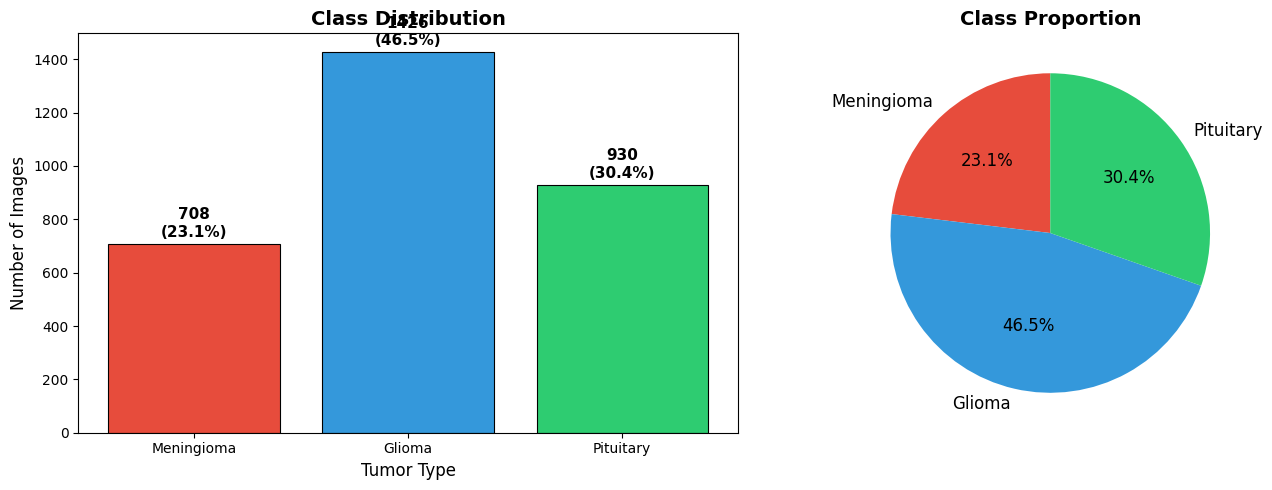


Class imbalance ratio (max/min): 2.01x
Note: Glioma is ~2x larger than Meningioma — moderate imbalance. Will use class weights.


In [21]:
class_counts = Counter(labels)
classes = [class_names[k] for k in sorted(class_counts.keys())]
counts = [class_counts[k] for k in sorted(class_counts.keys())]
colors = ['#e74c3c', '#3498db', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(classes, counts, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_xlabel('Tumor Type', fontsize=12)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 15,
                 f'{count}\n({count/len(labels)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=classes, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nClass imbalance ratio (max/min): {max(counts)/min(counts):.2f}x")
print("Note: Glioma is ~2x larger than Meningioma — moderate imbalance. Will use class weights.")

### 4.2 Sample Images from Each Class

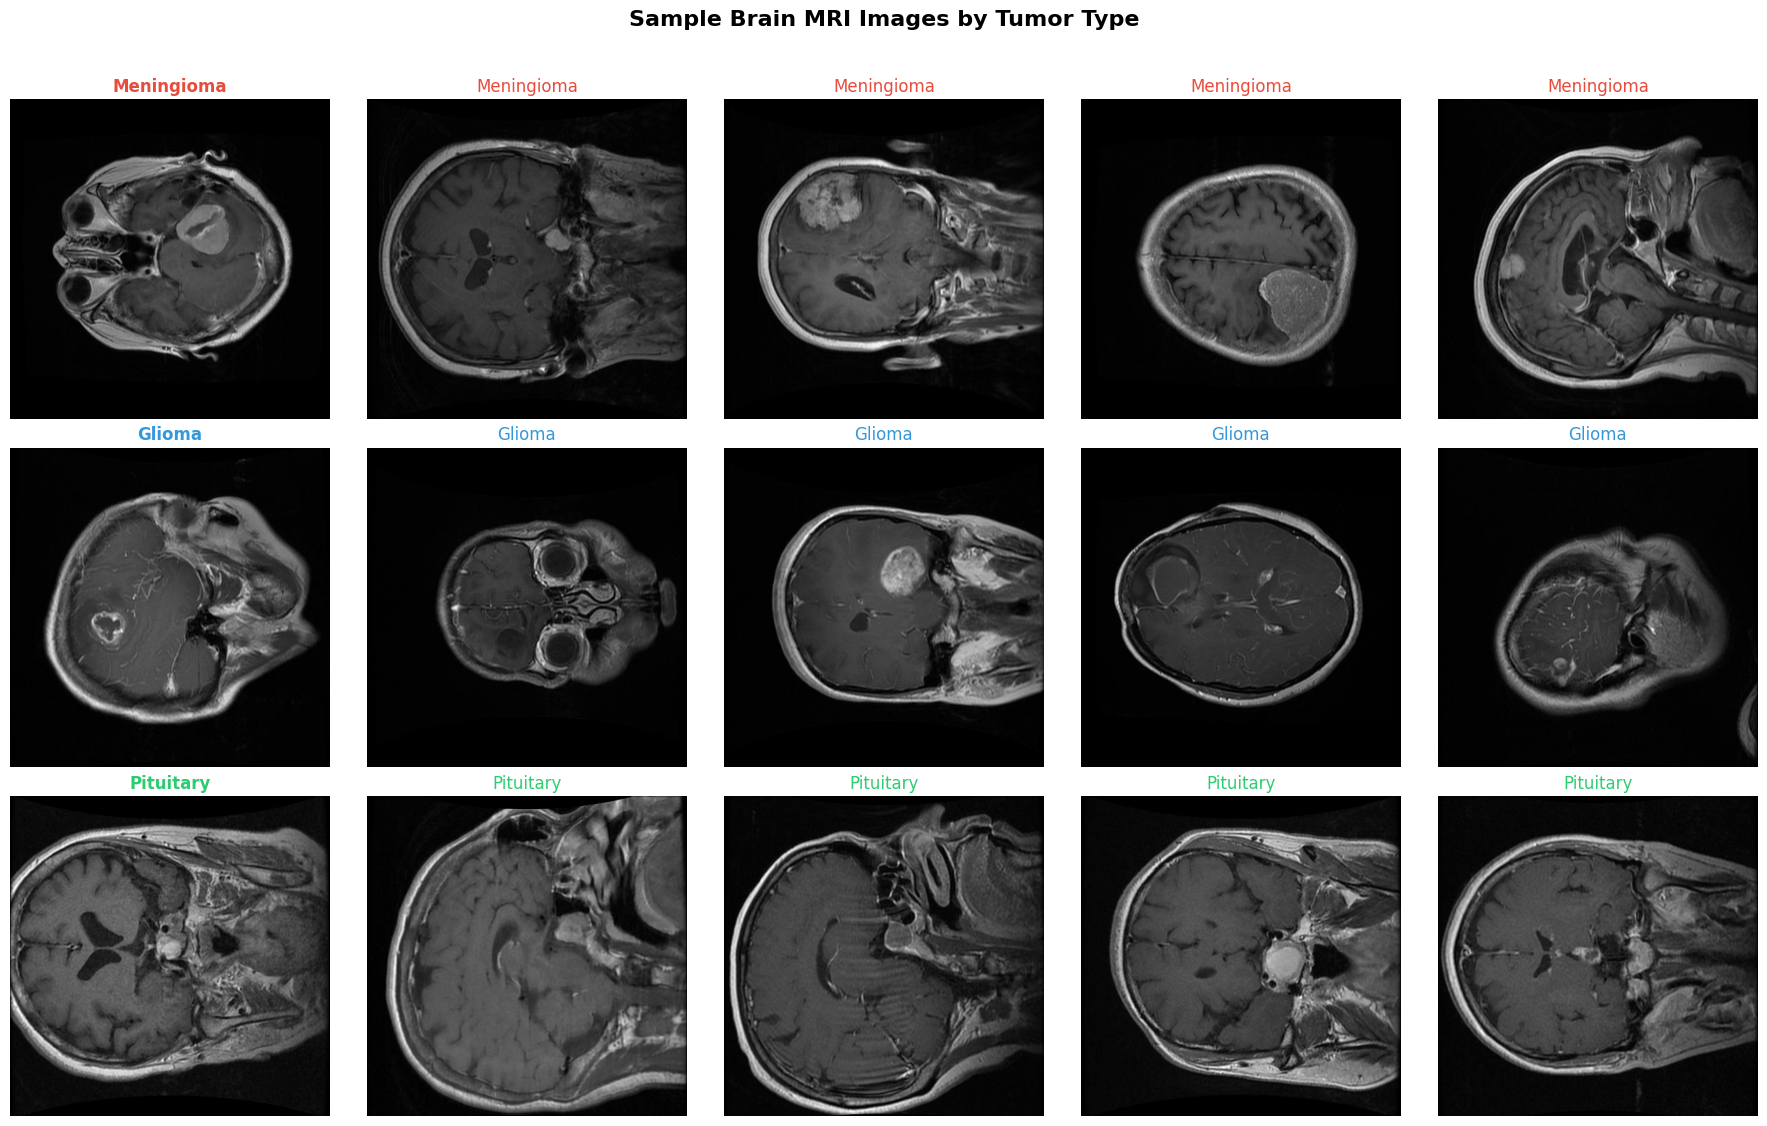

In [22]:
np.random.seed(42)
fig, axes = plt.subplots(3, 5, figsize=(18, 11))

for row, (cls, name) in enumerate(class_names.items()):
    cls_indices = np.where(labels == cls)[0]
    sample_indices = np.random.choice(cls_indices, 5, replace=False)
    for col, idx in enumerate(sample_indices):
        axes[row, col].imshow(training_data[idx][0])
        axes[row, col].axis('off')
        axes[row, col].set_title(name, fontsize=12, color=colors[row],
                                  fontweight='bold' if col == 0 else 'normal')

plt.suptitle('Sample Brain MRI Images by Tumor Type', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Pixel Intensity Distribution per Class

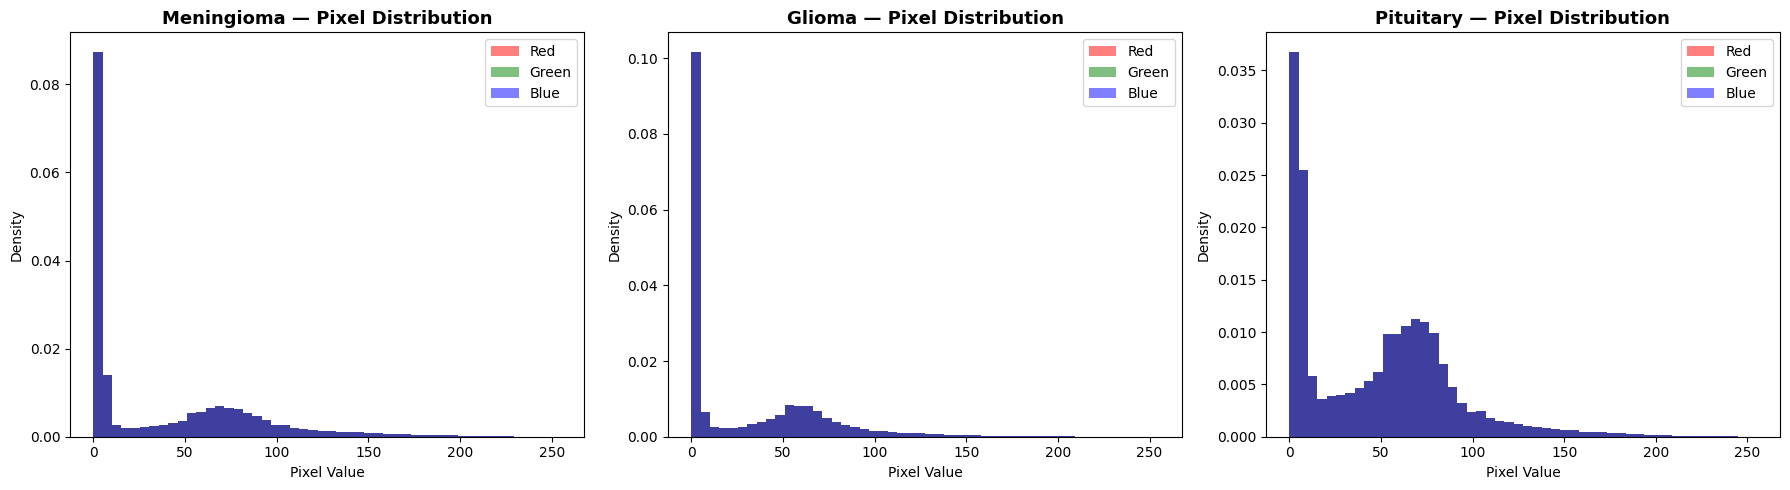

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (cls, name) in enumerate(class_names.items()):
    cls_idx = np.where(labels == cls)[0]
    sample_idx = np.random.choice(cls_idx, 30, replace=False)
    for ch, ch_name in enumerate(['Red', 'Green', 'Blue']):
        all_pixels = np.concatenate([training_data[j][0][:, :, ch].ravel() for j in sample_idx])
        axes[i].hist(all_pixels, bins=50, alpha=0.5, label=ch_name,
                     color=['red', 'green', 'blue'][ch], density=True)
        del all_pixels
    axes[i].set_title(f'{name} — Pixel Distribution', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Pixel Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.tight_layout()
plt.show()

### 4.4 Mean Image per Tumor Type

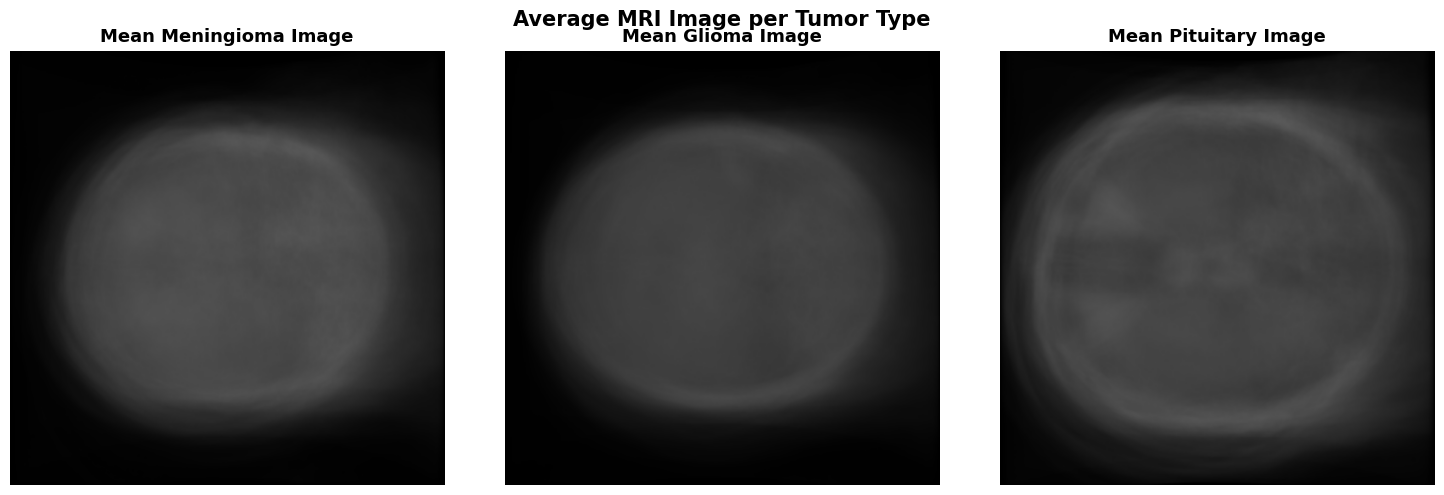

Observation: Mean images show distinct spatial patterns —
Pituitary tumors cluster centrally, while Glioma/Meningioma spread differently.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (cls, name) in enumerate(class_names.items()):
    cls_idx = np.where(labels == cls)[0]
    mean_img = np.zeros((512, 512, 3), dtype=np.float64)
    for j in cls_idx: 
        mean_img += training_data[j][0].astype(np.float64)
    mean_img = (mean_img / len(cls_idx)).astype(np.uint8)
    axes[i].imshow(mean_img)
    axes[i].set_title(f'Mean {name} Image', fontsize=13, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Average MRI Image per Tumor Type', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("Observation: Mean images show distinct spatial patterns —")
print("Pituitary tumors cluster centrally, while Glioma/Meningioma spread differently.")

## 5. Data Cleaning
### 5.1 Missing Values & Corrupt Image Check

In [25]:
print("Data Quality Checks:")
print("-" * 40)

# Check each image
bad_images = []
all_shapes = set()
for i, sample in enumerate(training_data):
    img = sample[0]
    all_shapes.add(img.shape)
    if not isinstance(img, np.ndarray):
        bad_images.append(i)
    elif img.shape != (512, 512, 3):
        bad_images.append(i)
    elif np.isnan(img.astype(float)).any():
        bad_images.append(i)

print(f"  Corrupt/bad images:    {len(bad_images)}")
print(f"  Unique shapes found:   {all_shapes}")
print(f"  All-zero images:       {sum(1 for s in training_data if s[0].sum() == 0)}")
print(f"  Labels in valid range: {set(np.unique(labels)).issubset({1, 2, 3})}")
print(f"  Label-image mismatch:  {len(training_data) != len(labels)}")

if len(bad_images) == 0:
    print("\n✅ Dataset is CLEAN — no missing values, no corrupt images, consistent shapes.")
else:
    print(f"\n⚠️  Found {len(bad_images)} problematic images at indices: {bad_images}")

Data Quality Checks:
----------------------------------------
  Corrupt/bad images:    0
  Unique shapes found:   {(512, 512, 3)}
  All-zero images:       0
  Labels in valid range: True
  Label-image mismatch:  False

✅ Dataset is CLEAN — no missing values, no corrupt images, consistent shapes.


### 5.2 Outlier Detection (Brightness Analysis)

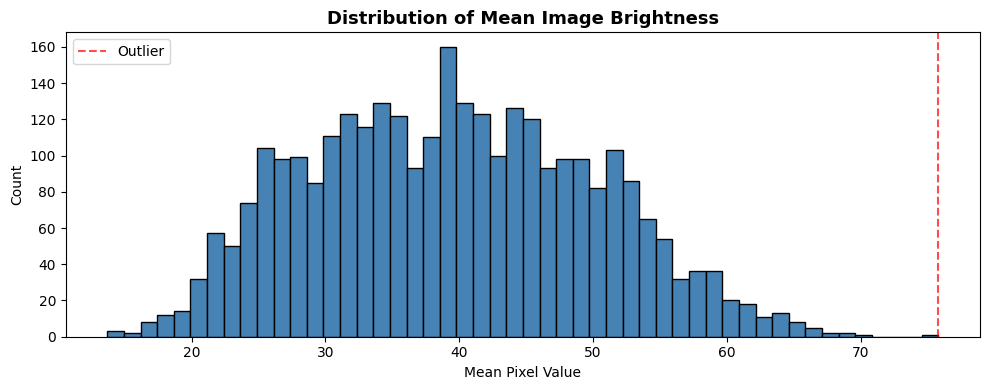

Mean brightness: 39.4 ± 10.6
Outlier images (beyond 3σ): 1
Decision: Outliers retained — they represent valid pathological variation, not data errors.


In [26]:
# Check for brightness outliers
brightness = np.array([training_data[i][0].mean() for i in range(len(training_data))])

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(brightness, bins=50, color='steelblue', edgecolor='black')
ax.set_title('Distribution of Mean Image Brightness', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Pixel Value')
ax.set_ylabel('Count')

mu, sigma = brightness.mean(), brightness.std()
outliers = np.where((brightness < mu - 3*sigma) | (brightness > mu + 3*sigma))[0]
for idx in outliers:
    ax.axvline(brightness[idx], color='red', linestyle='--', alpha=0.7, label='Outlier' if idx == outliers[0] else '')

if len(outliers) > 0:
    ax.legend()

plt.tight_layout()
plt.show()

print(f"Mean brightness: {mu:.1f} ± {sigma:.1f}")
print(f"Outlier images (beyond 3σ): {len(outliers)}")
print("Decision: Outliers retained — they represent valid pathological variation, not data errors.")

## 6. Data Manipulation & Preprocessing

Steps:
1. Resize images from 512×512 to 128×128 (reduces computation 16x)
2. Normalize pixel values to [0, 1]
3. Convert labels from 1-indexed to 0-indexed
4. One-hot encode labels
5. Stratified train/validation/test split (70/15/15)

In [27]:
# === Resize and normalize ===
IMG_SIZE = 128

print(f"Resizing {len(training_data)} images from 512x512 to {IMG_SIZE}x{IMG_SIZE}...")
X = np.zeros((len(training_data), IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)

for i in range(len(training_data)):
    X[i] = resize(training_data[i][0], (IMG_SIZE, IMG_SIZE, 3),
                  anti_aliasing=True, preserve_range=True).astype(np.float32)
    if (i + 1) % 500 == 0:
        print(f"  Processed {i+1}/{len(training_data)} images...")

# Normalize to [0, 1]
X = X / 255.0

# Free memory — no longer need raw data
del training_data
gc.collect()

print(f"\nX shape: {X.shape}")
print(f"X dtype: {X.dtype}")
print(f"Pixel range: [{X.min():.3f}, {X.max():.3f}]")
print(f"Memory: {X.nbytes / 1e6:.1f} MB")

Resizing 3064 images from 512x512 to 128x128...
  Processed 500/3064 images...
  Processed 1000/3064 images...
  Processed 1500/3064 images...
  Processed 2000/3064 images...
  Processed 2500/3064 images...
  Processed 3000/3064 images...

X shape: (3064, 128, 128, 3)
X dtype: float32
Pixel range: [0.000, 0.970]
Memory: 602.4 MB


In [28]:
# === Label encoding ===
y = labels - 1  # Convert 1,2,3 → 0,1,2
y_onehot = to_categorical(y, num_classes=3)
print(f"Original labels: {np.unique(labels)} → Encoded: {np.unique(y)}")
print(f"One-hot shape: {y_onehot.shape}")

Original labels: [1 2 3] → Encoded: [0 1 2]
One-hot shape: (3064, 3)


In [29]:
# === Stratified Train/Val/Test Split ===
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_onehot, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp.argmax(axis=1)
)

del X, X_temp, y_temp
gc.collect()

print(f"Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(labels)*100:.0f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(labels)*100:.0f}%)")
print(f"Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(labels)*100:.0f}%)")

# Verify stratification preserved
print("\nStratification check:")
for name, split_y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    dist = np.bincount(split_y.argmax(axis=1))
    pcts = dist / dist.sum() * 100
    print(f"  {name:5s}: Meningioma={pcts[0]:.1f}%  Glioma={pcts[1]:.1f}%  Pituitary={pcts[2]:.1f}%")

Training set:   2144 samples (70%)
Validation set: 460 samples (15%)
Test set:       460 samples (15%)

Stratification check:
  Train: Meningioma=23.1%  Glioma=46.5%  Pituitary=30.4%
  Val  : Meningioma=23.0%  Glioma=46.5%  Pituitary=30.4%
  Test : Meningioma=23.3%  Glioma=46.5%  Pituitary=30.2%


### Data Augmentation

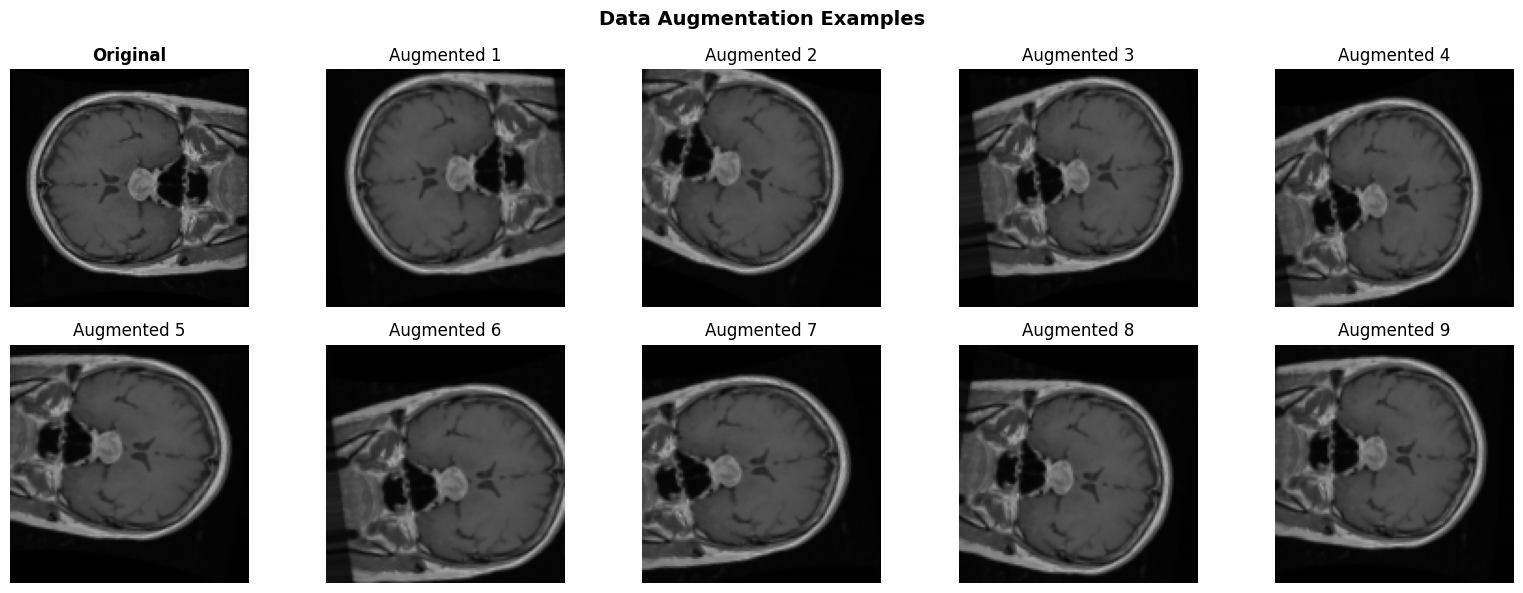

Augmentation: rotation, shift, flip, zoom, shear
Purpose: Increase effective training data, reduce overfitting


In [30]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    shear_range=0.05,
    fill_mode='nearest'
)

# Visualize augmented samples
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
sample_img = X_train[0]

axes[0, 0].imshow(sample_img)
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

for i in range(1, 10):
    row, col = divmod(i, 5)
    aug_img = train_datagen.random_transform(sample_img)
    axes[row, col].imshow(aug_img)
    axes[row, col].set_title(f'Augmented {i}')
    axes[row, col].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Augmentation: rotation, shift, flip, zoom, shear")
print("Purpose: Increase effective training data, reduce overfitting")

## 7. Model Building — CNN Architecture

| Block | Layers | Filters | Output Shape |
|-------|--------|---------|-------------|
| Conv Block 1 | Conv2D×2 + BN + MaxPool + Dropout | 32 | 64×64 |
| Conv Block 2 | Conv2D×2 + BN + MaxPool + Dropout | 64 | 32×32 |
| Conv Block 3 | Conv2D×2 + BN + MaxPool + Dropout | 128 | 16×16 |
| Classifier | Flatten → Dense(256) → Dense(128) → Dense(3) | — | 3 |

**Regularization:** BatchNorm, Dropout (0.25 conv / 0.5 dense), L2 weight decay

In [31]:
model = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Classifier head
    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 8,711,971 (33.23 MB)

 Trainable params: 8,710,563 (33.23 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [32]:
# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

print(f"Total parameters: {model.count_params():,}")
print(f"Optimizer: Adam (lr=0.001)")
print(f"Loss: Categorical Crossentropy")

Total parameters: 8,711,971
Optimizer: Adam (lr=0.001)
Loss: Categorical Crossentropy


### Training

In [33]:
# Compute class weights for imbalanced data
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weights = {i: w for i, w in enumerate(class_weights_arr)}
print(f"Class weights: { {class_names[i+1]: f'{w:.3f}' for i, w in class_weights.items()} }")

# Training parameters
BATCH_SIZE = 32
EPOCHS = 15

train_generator = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE)

# Train
history = model.fit(
    train_generator,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\nTraining completed in {len(history.history['loss'])} epochs.")
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Best val_loss: {min(history.history['val_loss']):.4f}")

Class weights: {'Meningioma': '1.443', 'Glioma': '0.716', 'Pituitary': '1.098'}
Epoch 1/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.5625 - loss: 2.0550 - val_accuracy: 0.4652 - val_loss: 3.2688 - learning_rate: 0.0010
Epoch 2/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.6287 - loss: 1.8392 - val_accuracy: 0.3043 - val_loss: 2.4211 - learning_rate: 0.0010
Epoch 3/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.6614 - loss: 1.6889 - val_accuracy: 0.3043 - val_loss: 3.2071 - learning_rate: 0.0010
Epoch 4/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.7304 - loss: 1.4621 - val_accuracy: 0.3043 - val_loss: 3.2198 - learning_rate: 0.0010
Epoch 5/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.7183 - loss: 1.4287 - val_accuracy: 0.3043 - val_loss: 3.3384 - learning_rate: 0.0010
Epoch 6/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.7635 - loss: 1.3140 - val_accuracy: 0.4761 - val_loss: 2.7580 - learning_rate: 0.0010
Epoch 7/15
67/6

## 8. Model Evaluation
### 8.1 Training & Validation Curves

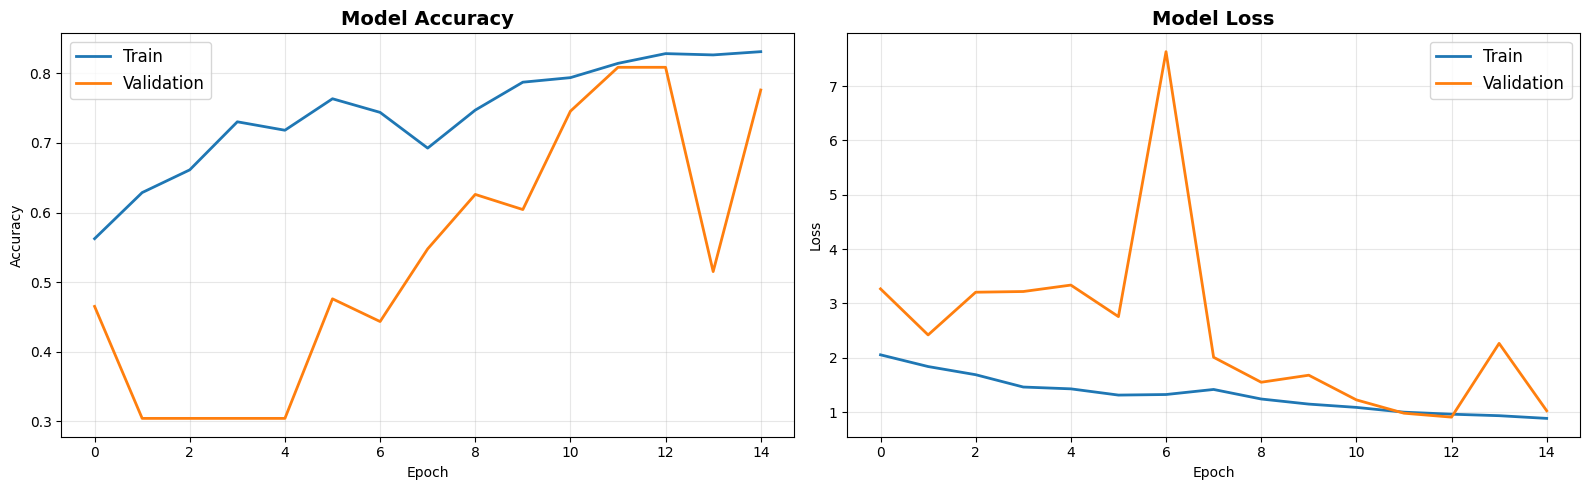

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8.2 Test Set Performance

In [35]:
# Evaluate on held-out test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"{'='*55}")
print(f"TEST SET RESULTS")
print(f"{'='*55}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"Test Loss:     {test_loss:.4f}")

# Detailed classification report
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

target_names = ['Meningioma', 'Glioma', 'Pituitary']
print(f"\n{'='*55}")
print("CLASSIFICATION REPORT")
print(f"{'='*55}")
print(classification_report(y_true_classes, y_pred_classes, target_names=target_names))

TEST SET RESULTS
Test Accuracy: 0.8283 (82.8%)
Test Loss:     0.8943

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Meningioma       0.73      0.52      0.61       107
      Glioma       0.84      0.91      0.87       214
   Pituitary       0.87      0.94      0.90       139

    accuracy                           0.83       460
   macro avg       0.81      0.79      0.79       460
weighted avg       0.82      0.83      0.82       460



### 8.3 Confusion Matrix

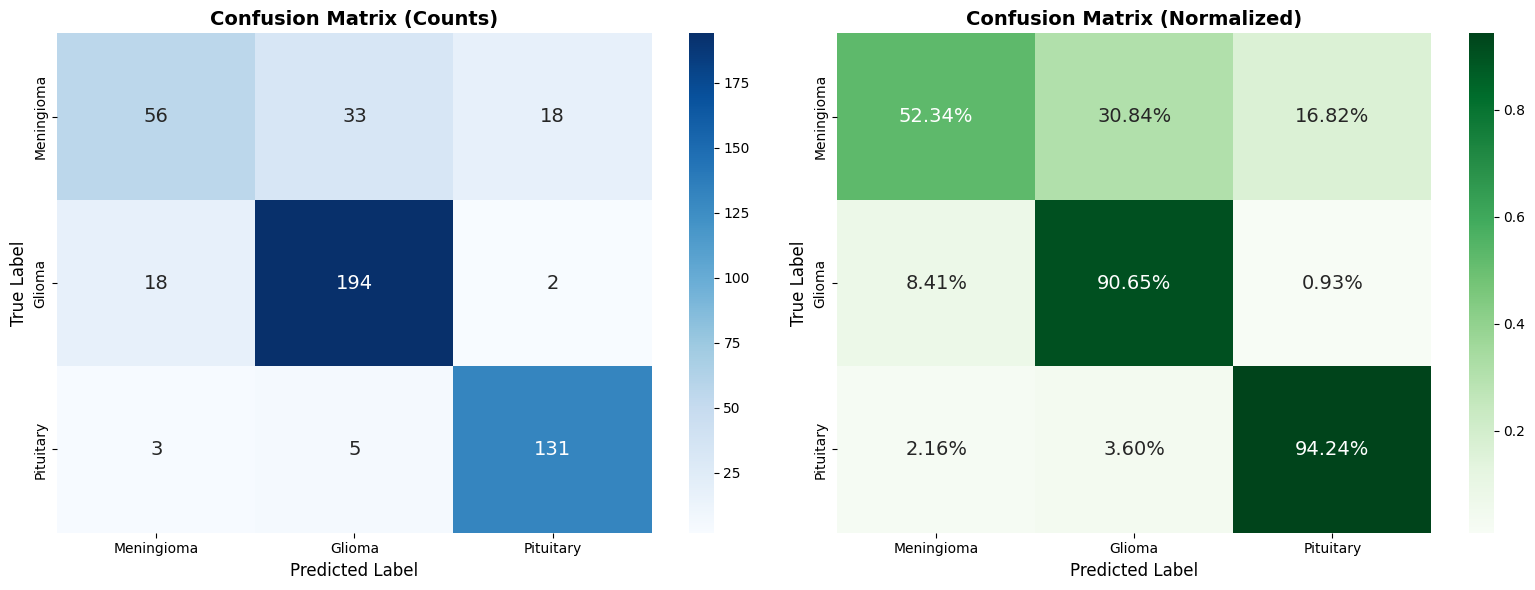

In [36]:
cm = confusion_matrix(y_true_classes, y_pred_classes)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=axes[0],
            annot_kws={'size': 14})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names, ax=axes[1],
            annot_kws={'size': 14})
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()

### 8.4 Sample Predictions

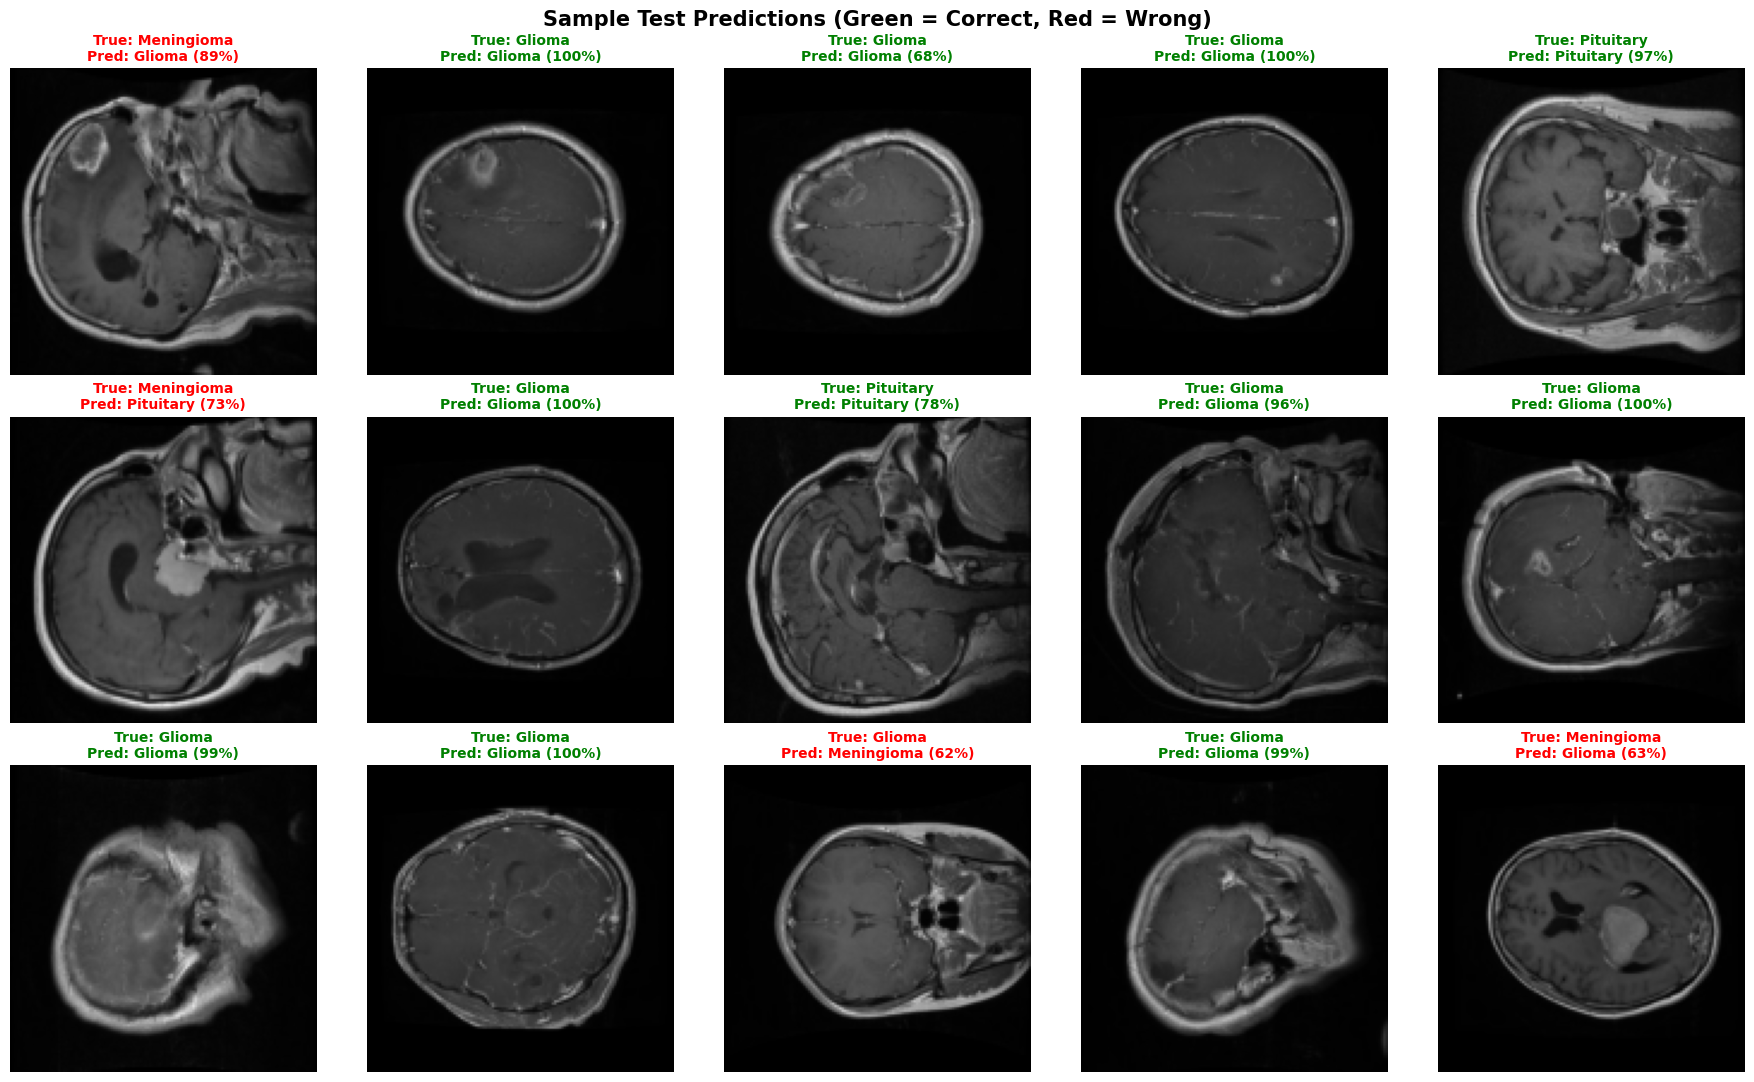

In [37]:
fig, axes = plt.subplots(3, 5, figsize=(18, 11))

for i in range(15):
    row, col = divmod(i, 5)
    idx = np.random.randint(len(X_test))
    axes[row, col].imshow(X_test[idx])
    axes[row, col].axis('off')

    true_label = target_names[y_true_classes[idx]]
    pred_label = target_names[y_pred_classes[idx]]
    conf = y_pred[idx].max() * 100

    color = 'green' if true_label == pred_label else 'red'
    axes[row, col].set_title(f'True: {true_label}\nPred: {pred_label} ({conf:.0f}%)',
                              fontsize=10, color=color, fontweight='bold')

plt.suptitle('Sample Test Predictions (Green = Correct, Red = Wrong)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Predictions on Unseen Test Images

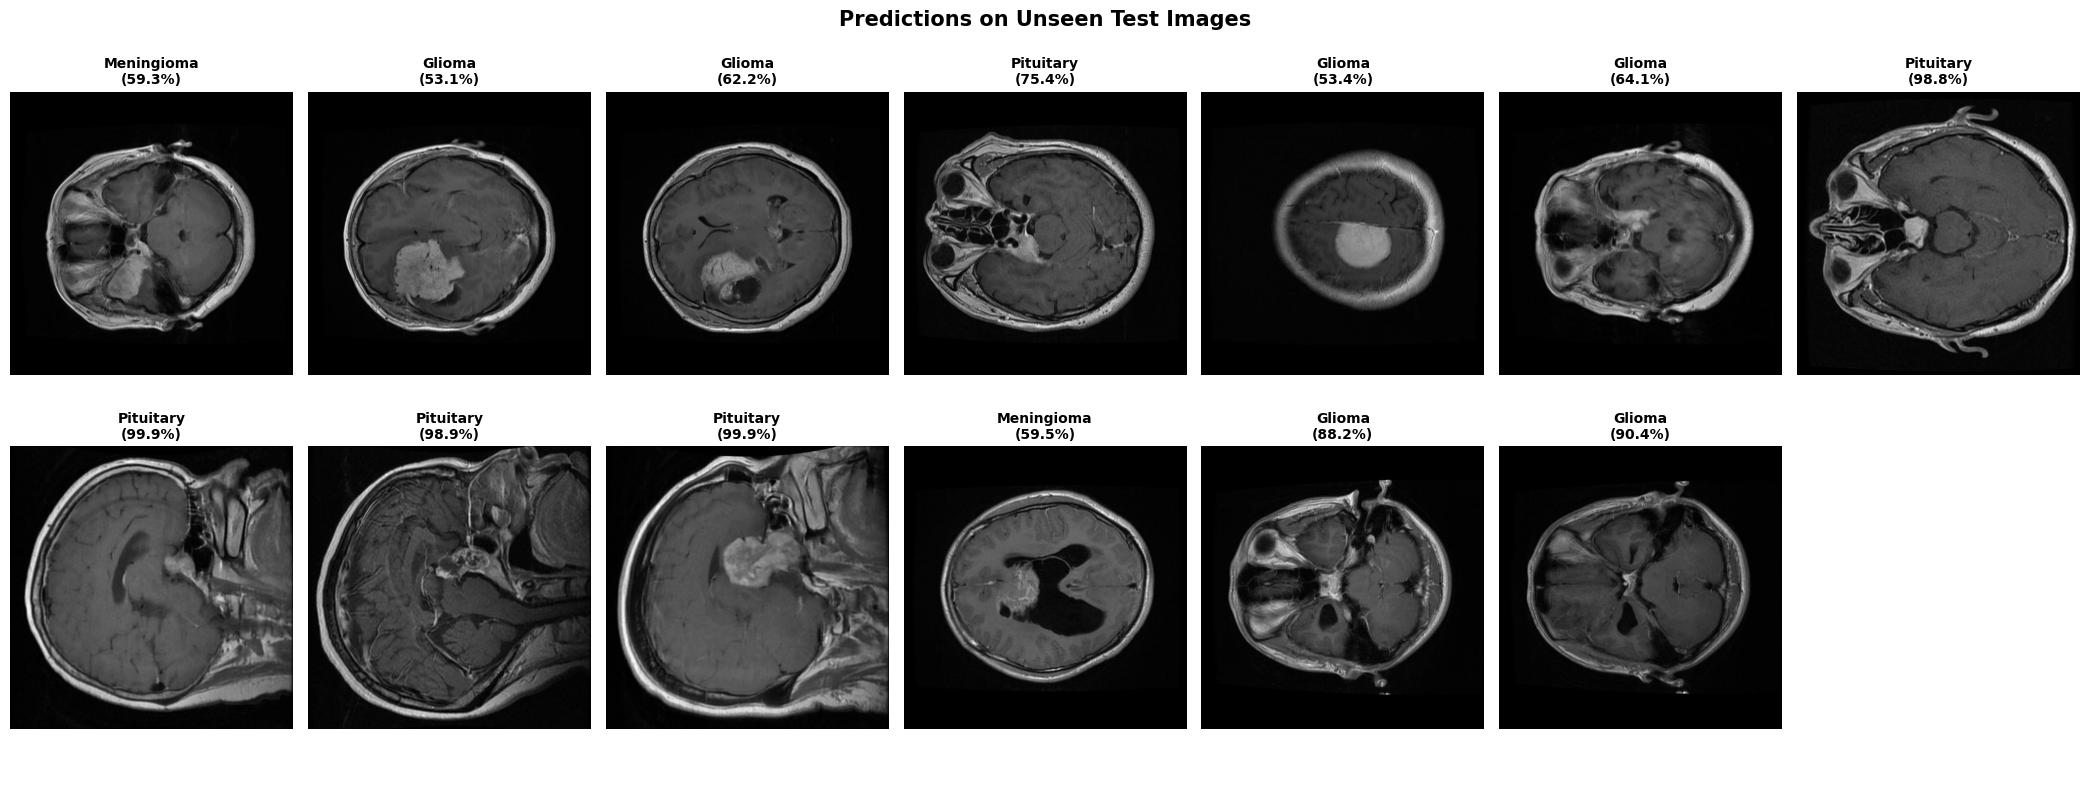

In [38]:
from skimage.io import imread

test_dir = 'test_images-20210704T210303Z-001/test_images'

if os.path.exists(test_dir):
    test_files = sorted([f for f in os.listdir(test_dir)
                         if f.lower().endswith(('.jpg', '.png', '.jpeg'))])

    if test_files:
        n = len(test_files)
        cols = min(7, n)
        rows = (n + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 4*rows))
        axes = np.array(axes).flatten()

        for i, fname in enumerate(test_files):
            img = imread(os.path.join(test_dir, fname))
            img_resized = resize(img, (IMG_SIZE, IMG_SIZE, 3),
                                 anti_aliasing=True, preserve_range=True).astype(np.float32) / 255.0

            pred = model.predict(img_resized[np.newaxis, ...], verbose=0)
            pred_class = target_names[np.argmax(pred)]
            confidence = pred.max() * 100

            axes[i].imshow(img)
            axes[i].set_title(f'{pred_class}\n({confidence:.1f}%)',
                              fontsize=10, fontweight='bold')
            axes[i].axis('off')

        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle('Predictions on Unseen Test Images', fontsize=15, fontweight='bold')
        plt.tight_layout()
        plt.show()
else:
    print(f"Test directory not found: {test_dir}")

## 10. Save Model

In [40]:
# Save in .keras format (recommended for Keras 3+)
model.save('brain_tumor_cnn_model.keras')
print("Model saved: brain_tumor_cnn_model.keras")

# Save training history
import json
hist = {k: [float(v) for v in vals] for k, vals in history.history.items()}
with open('training_history.json', 'w') as f:
    json.dump(hist, f, indent=2)
print("History saved: training_history.json")

Model saved: brain_tumor_cnn_model.keras
History saved: training_history.json


In [41]:
model.export('brain_tumor_cnn_savedmodel')

INFO:tensorflow:Assets written to: brain_tumor_cnn_savedmodel\assets


INFO:tensorflow:Assets written to: brain_tumor_cnn_savedmodel\assets


Saved artifact at 'brain_tumor_cnn_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_32')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2260968945424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2260968940048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2260968945616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2260147659280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2260968945040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2260968945232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2260147659856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2260147658896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2260147659664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2260147658128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2260147658704: Tensor

## 11. Conclusion

### Summary
- Built a **3-block CNN** (32→64→128 filters) for classifying brain MRI tumors into Meningioma, Glioma, and Pituitary categories
- Applied **data augmentation**, **class weighting**, and **regularization** (BatchNorm, Dropout, L2) to handle class imbalance and prevent overfitting
- Used **EarlyStopping** and **ReduceLROnPlateau** callbacks for efficient training

### Key Decisions
| Decision | Rationale |
|----------|-----------|
| Resize to 128×128 | 16x less compute vs 512×512, retains tumor structure |
| Class weights | Compensates for 2:1 Glioma/Meningioma imbalance |
| Data augmentation | Rotation, flip, zoom — standard for medical imaging |
| 3 Conv blocks | Sufficient depth for 128×128 input without vanishing gradients |

### Future Improvements
- **Transfer Learning** (ResNet50, EfficientNet) for potentially higher accuracy
- **Grad-CAM** visualization to show which brain regions drive predictions
- **Larger input size** (224×224) with GPU training
- **Cross-validation** for more robust accuracy estimates
- Collect more Meningioma samples to reduce class imbalance

---
*Project completed as part of CNN Capstone — Innomatics Research Labs*